In [ ]:
!pip -q install tensorflow tensorflow-datasets hdbscan librosa

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from itertools import combinations

import tensorflow as tf
import tensorflow_datasets as tfds
import librosa

from sklearn.preprocessing import normalize
from sklearn.random_projection import SparseRandomProjection
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception as e:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available:", e)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
ds = tfds.load("spoken_digit", split="train", as_supervised=False)

texts = []
waveforms = []
y_true = []

SELECTED_DIGITS = [0, 1, 2, 3]

for ex in tfds.as_numpy(ds):
    label = int(ex["label"])
    if label not in SELECTED_DIGITS:
        continue

    audio = ex["audio"].astype(np.float32)

    max_abs = np.max(np.abs(audio)) + 1e-12
    audio = audio / max_abs

    waveforms.append(audio)
    y_true.append(SELECTED_DIGITS.index(label))

waveforms = np.array(waveforms, dtype=object)
y_true = np.array(y_true)

target_names = [str(x) for x in SELECTED_DIGITS]

print("Number of samples:", len(waveforms))
print("Selected classes:", target_names)
print("Class counts:", {name: int(np.sum(y_true == i)) for i, name in enumerate(target_names)})

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Shuffling /root/tensorflow_datasets/spoken_digit/incomplete.AAHKQ9_1.0.9/spoken_digit-train.tfrecord*...:   0%…

Dataset spoken_digit downloaded and prepared to /root/tensorflow_datasets/spoken_digit/1.0.9. Subsequent calls will reuse this data.
Number of samples: 1000
Selected classes: ['0', '1', '2', '3']
Class counts: {'0': 250, '1': 250, '2': 250, '3': 250}


In [ ]:
TARGET_SR = 8000
FIXED_LEN = 8000
def pad_or_trim(x, fixed_len=8000):
    if len(x) < fixed_len:
        return np.pad(x, (0, fixed_len - len(x)))
    return x[:fixed_len]

waveforms_fixed = np.stack([pad_or_trim(x, FIXED_LEN) for x in waveforms]).astype(np.float32)

def extract_logmel_features(
    waveforms,
    sr=8000,
    n_mels=64,
    n_fft=256,
    hop_length=80,
    win_length=200
):
    feats = []
    for x in waveforms:
        mel = librosa.feature.melspectrogram(
            y=x,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
            power=2.0
        )
        logmel = librosa.power_to_db(mel, ref=np.max)
        feats.append(logmel.flatten())
    return np.array(feats, dtype=np.float32)

X_feat = extract_logmel_features(waveforms_fixed, sr=TARGET_SR)
X_feat = normalize(X_feat, norm="l2", axis=1)

print("Feature matrix shape:", X_feat.shape)

Feature matrix shape: (1000, 6464)


In [ ]:
JL_DIM = 256

rp = SparseRandomProjection(
    n_components=JL_DIM,
    dense_output=True,
    random_state=42
)

t0 = time.perf_counter()
X_jl = rp.fit_transform(X_feat)
jl_time = time.perf_counter() - t0

X_jl = normalize(X_jl, norm="l2", axis=1)

print("JL shape:", X_jl.shape)
print("JL time:", jl_time)

JL shape: (1000, 256)
JL time: 0.08281215600001701


Mean abs distortion: 0.0016452741
95% abs distortion: 0.0049148854


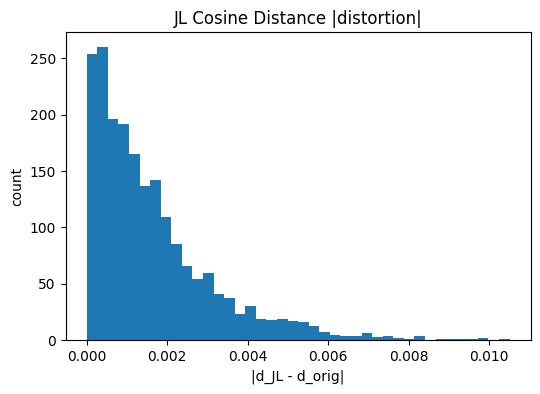

In [ ]:
rng = np.random.default_rng(0)
n = X_feat.shape[0]
pairs = 2000

idx_a = rng.integers(0, n, size=pairs)
idx_b = rng.integers(0, n, size=pairs)

orig_sim = np.sum(X_feat[idx_a] * X_feat[idx_b], axis=1)
orig_dist = 1.0 - orig_sim

jl_sim = np.sum(X_jl[idx_a] * X_jl[idx_b], axis=1)
jl_dist = 1.0 - jl_sim

abs_distortion = np.abs(jl_dist - orig_dist)

print("Mean abs distortion:", abs_distortion.mean())
print("95% abs distortion:", np.quantile(abs_distortion, 0.95))

plt.figure(figsize=(6,4))
plt.hist(abs_distortion, bins=40)
plt.title("JL Cosine Distance |distortion|")
plt.xlabel("|d_JL - d_orig|")
plt.ylabel("count")
plt.show()

In [ ]:
k = len(np.unique(y_true))

t0 = time.perf_counter()
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_km = kmeans.fit_predict(X_jl)
km_time = time.perf_counter() - t0
print("KMeans time:", km_time)

if HDBSCAN_AVAILABLE:
    t0 = time.perf_counter()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=10,
        min_samples=4,
        metric="euclidean"
    )
    y_hdb = clusterer.fit_predict(X_jl)
    hdb_time = time.perf_counter() - t0
    print("HDBSCAN time:", hdb_time)
    print("HDBSCAN clusters (excluding -1):", len(set(y_hdb)) - (1 if -1 in y_hdb else 0))
else:
    y_hdb = None
    hdb_time = None

KMeans time: 0.21069463800000676
HDBSCAN time: 0.6472794969999995
HDBSCAN clusters (excluding -1): 6


In [ ]:
def random_hyperplane_hash(X, hyperplanes):
    proj = X @ hyperplanes.T
    return proj >= 0.0

def bits_to_int(bit_row):
    out = 0
    for b in bit_row:
        out = (out << 1) | int(b)
    return out

def lsh_candidate_buckets(bits, band_size):
    n, n_bits = bits.shape
    assert n_bits % band_size == 0
    n_bands = n_bits // band_size

    tables = []
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        table = defaultdict(list)
        for i in range(n):
            key = bits_to_int(bits[i, start:end])
            table[key].append(i)
        tables.append(table)
    return tables

def build_candidate_pairs(tables, max_bucket_size=200):
    cand = set()
    for table in tables:
        for _, idxs in table.items():
            if len(idxs) < 2:
                continue
            if len(idxs) > max_bucket_size:
                continue
            for i, j in combinations(idxs, 2):
                cand.add((min(i, j), max(i, j)))
    return cand

def connected_components(n, edges):
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, j in edges:
        union(i, j)

    roots = np.array([find(i) for i in range(n)])
    _, labels = np.unique(roots, return_inverse=True)
    return labels

In [ ]:
N_BITS = 96
BAND_SIZE = 12
COS_THRESHOLD = 0.72
MAX_BUCKET = 200

rng = np.random.default_rng(42)
d = X_jl.shape[1]

hyperplanes = rng.normal(size=(N_BITS, d)).astype(np.float32)
hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12

t0 = time.perf_counter()

bits = random_hyperplane_hash(X_jl, hyperplanes)
tables = lsh_candidate_buckets(bits, band_size=BAND_SIZE)
cand_pairs = build_candidate_pairs(tables, max_bucket_size=MAX_BUCKET)

mid = time.perf_counter()

edges = []
for i, j in cand_pairs:
    sim = float(np.dot(X_jl[i], X_jl[j]))
    if sim >= COS_THRESHOLD:
        edges.append((i, j))

y_lsh = connected_components(n=X_jl.shape[0], edges=edges)

lsh_time = time.perf_counter() - t0
hash_time = mid - t0
refine_time = lsh_time - hash_time

print("LSH candidates:", len(cand_pairs))
print("LSH edges kept:", len(edges))
print("LSH clusters:", len(np.unique(y_lsh)))
print("LSH total time:", lsh_time)
print("Hash time:", hash_time)
print("Refine time:", refine_time)

LSH candidates: 85757
LSH edges kept: 85757
LSH clusters: 83
LSH total time: 0.55458093499999
Hash time: 0.16257039800001394
Refine time: 0.392010536999976


In [ ]:
def purity_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    N = len(y_true)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        _, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / N

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels, metric="euclidean")

In [ ]:
rows = []

rows.append({
    "method": "KMeans (on JL)",
    "time_sec": km_time,
    "ARI": adjusted_rand_score(y_true, y_km),
    "NMI": normalized_mutual_info_score(y_true, y_km),
    "Purity": purity_score(y_true, y_km),
    "Silhouette": safe_silhouette(X_jl, y_km),
    "n_clusters": len(np.unique(y_km))
})

if HDBSCAN_AVAILABLE and y_hdb is not None:
    y_hdb_non_noise = y_hdb[y_hdb != -1]
    X_hdb_non_noise = X_jl[y_hdb != -1]

    sil = np.nan
    if len(y_hdb_non_noise) > 1 and len(np.unique(y_hdb_non_noise)) >= 2:
        sil = silhouette_score(X_hdb_non_noise, y_hdb_non_noise, metric="euclidean")

    rows.append({
        "method": "HDBSCAN (on JL)",
        "time_sec": hdb_time,
        "ARI": adjusted_rand_score(y_true, y_hdb),
        "NMI": normalized_mutual_info_score(y_true, y_hdb),
        "Purity": purity_score(y_true, y_hdb),
        "Silhouette": sil,
        "n_clusters": len(set(y_hdb)) - (1 if -1 in y_hdb else 0)
    })

rows.append({
    "method": "JL + Random-Hyperplane LSH (custom)",
    "time_sec": lsh_time,
    "ARI": adjusted_rand_score(y_true, y_lsh),
    "NMI": normalized_mutual_info_score(y_true, y_lsh),
    "Purity": purity_score(y_true, y_lsh),
    "Silhouette": safe_silhouette(X_jl, y_lsh),
    "n_clusters": len(np.unique(y_lsh))
})

results = pd.DataFrame(rows).sort_values("time_sec")
results

,method,time_sec,ARI,NMI,Purity,Silhouette,n_clusters
0,KMeans (on JL),0.210695,0.060310,0.101442,0.395,0.219021,4
2,JL + Random-Hyperplane LSH (custom),0.554581,0.000098,0.112287,0.318,-0.449262,83
1,HDBSCAN (on JL),0.647279,0.031627,0.205585,0.417,0.172275,6


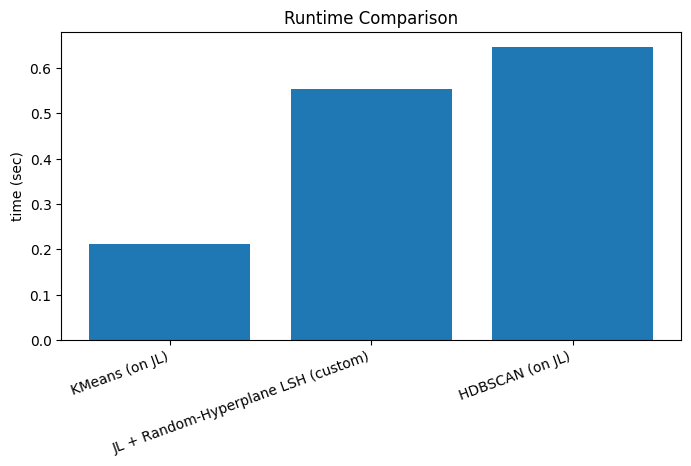

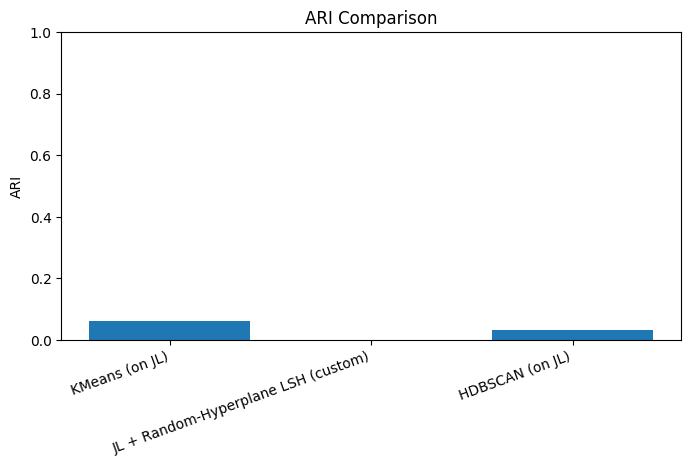

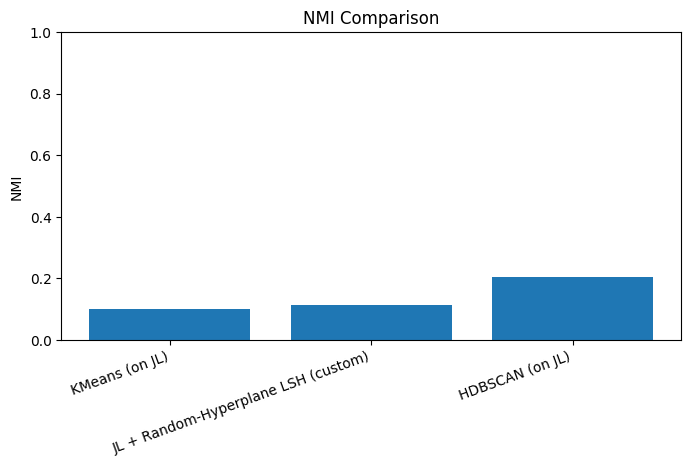

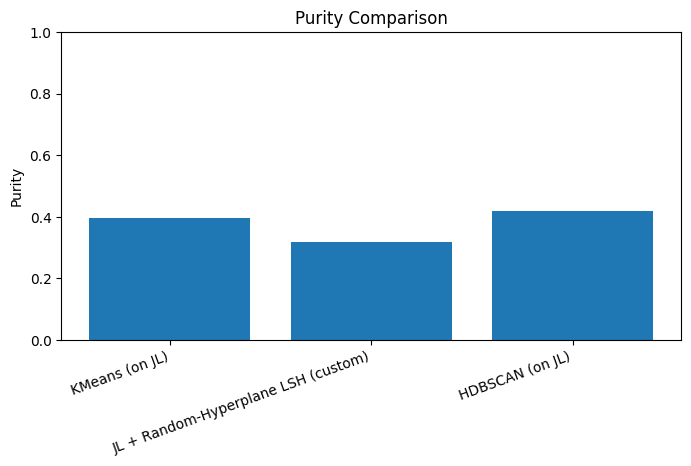

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results["method"], results["time_sec"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("time (sec)")
plt.title("Runtime Comparison")
plt.show()

for metric in ["ARI", "NMI", "Purity"]:
    plt.figure(figsize=(8,4))
    plt.bar(results["method"], results[metric])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1.0)
    plt.show()

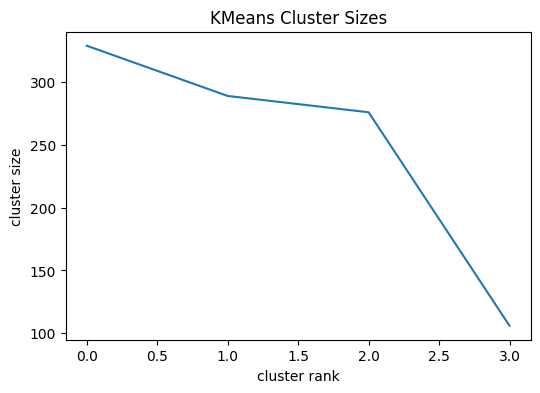

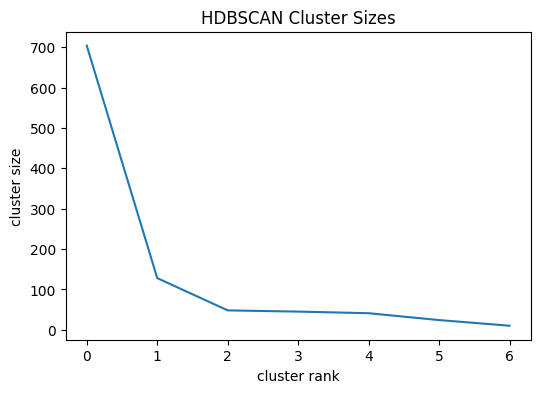

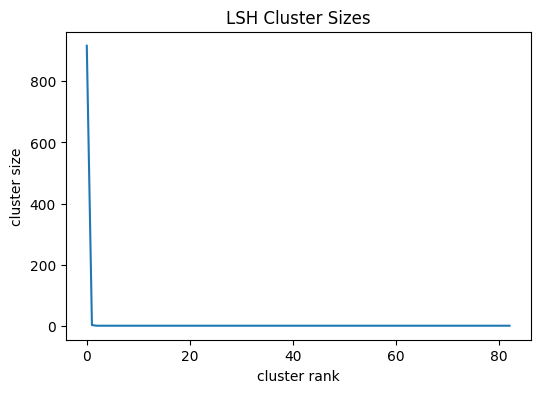

In [ ]:
def plot_cluster_sizes(labels, title):
    _, counts = np.unique(labels, return_counts=True)
    counts = np.sort(counts)[::-1]
    plt.figure(figsize=(6,4))
    plt.plot(counts)
    plt.xlabel("cluster rank")
    plt.ylabel("cluster size")
    plt.title(title)
    plt.show()

plot_cluster_sizes(y_km, "KMeans Cluster Sizes")

if HDBSCAN_AVAILABLE and y_hdb is not None:
    plot_cluster_sizes(y_hdb, "HDBSCAN Cluster Sizes")

plot_cluster_sizes(y_lsh, "LSH Cluster Sizes")

In [ ]:
def augment_audio(x, noise_std=0.01, shift=120, seed=0):
    rng = np.random.default_rng(seed)
    y = np.roll(x, shift)
    y = y + rng.normal(0, noise_std, size=len(y)).astype(np.float32)
    y = np.clip(y, -1.0, 1.0)
    return y

dup_count = min(100, len(waveforms_fixed) // 4)
rng = np.random.default_rng(123)
base_idx = rng.choice(len(waveforms_fixed), size=dup_count, replace=False)

dup_waveforms = [
    augment_audio(waveforms_fixed[i], noise_std=0.01, shift=100, seed=int(i))
    for i in base_idx
]

aug_waveforms = np.concatenate(
    [waveforms_fixed, np.array(dup_waveforms, dtype=np.float32)],
    axis=0
)

N0 = len(waveforms_fixed)
dup_pairs = [(int(i), N0 + k) for k, i in enumerate(base_idx)]

X_aug = extract_logmel_features(aug_waveforms, sr=TARGET_SR)
X_aug = normalize(X_aug, norm="l2", axis=1)

X_aug_jl = rp.fit_transform(X_aug)
X_aug_jl = normalize(X_aug_jl, norm="l2", axis=1)

t0 = time.perf_counter()

bits_aug = random_hyperplane_hash(X_aug_jl, hyperplanes)
tables_aug = lsh_candidate_buckets(bits_aug, band_size=BAND_SIZE)
cand_aug = build_candidate_pairs(tables_aug, max_bucket_size=MAX_BUCKET)

edges_aug = []
for i, j in cand_aug:
    if float(np.dot(X_aug_jl[i], X_aug_jl[j])) >= COS_THRESHOLD:
        edges_aug.append((i, j))

labels_aug = connected_components(n=X_aug_jl.shape[0], edges=edges_aug)
dup_time = time.perf_counter() - t0

hits = sum(1 for a, b in dup_pairs if labels_aug[a] == labels_aug[b])
dup_recall = hits / len(dup_pairs)

print("Duplicate recall (LSH components):", dup_recall)
print("Time on augmented dataset:", dup_time)

Duplicate recall (LSH components): 0.87
Time on augmented dataset: 0.478794430999983


In [ ]:
results.to_csv("experiment4_spoken_digit_results.csv", index=False)
print("Saved: experiment4_spoken_digit_results.csv")

Saved: experiment4_spoken_digit_results.csv
